# Spark 03: Machine Learning a Escala con Spark MLlib
Universidad del Valle de Guatemala — Data Science

En esta práctica construiremos y evaluaremos un pipeline de Machine Learning distribuido para predecir los puntos anotados (`PTS`) por un jugador de la NBA a partir de estadísticas de rendimiento en cancha. Aprenderemos a prevenir la fuga de información (*Data Leakage*), realizar muestreo seguro para análisis exploratorio, vectorizar variables con `VectorAssembler`, entrenar modelos de regresión lineal y evaluar diagnósticos de residuos a escala.

Nina Nájera
231088

### 1. Verificación del Entorno de Ejecución
Comprobamos la compatibilidad de Java 17 y la versión de PySpark activa en el contenedor Docker.

In [1]:
import os
import pyspark


print("JAVA_HOME:", os.environ.get("JAVA_HOME"))
print("PySpark:", pyspark.__version__)

JAVA_HOME: /usr/lib/jvm/java-17-openjdk-amd64
PySpark: 3.5.1


### 2. Inicialización de la sesión de spark
Inicializamos la sesión de Spark configurando el motor en modo local con todos los hilos del CPU.

In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("NotebookPySpark")
    .master("local[*]")
    .config("spark.driver.host", "127.0.0.1")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

print("Spark:", spark.version)
print("Java:", spark.sparkContext._jvm.java.lang.System.getProperty("java.version"))

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/21 23:57:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 3.5.1
Java: 17.0.20.1


### 3. Definición de la Carpeta de Trabajo
Establecemos la ruta hacia los datos de la NBA montados en `/opt/app/working_dir/`.

In [3]:
mydir = "/opt/app/working_dir/"

### 4. Carga del Dataset de la NBA (`games_details.csv`)
Cargamos las estadísticas individuales por partido con inferencia de esquema y encabezado activados.

In [4]:
nba = spark.read.csv( 
  header = True, 
  inferSchema = True, 
  path = mydir + 'nba/games_details.csv' 
) 
nba.printSchema()

root
 |-- GAME_ID: integer (nullable = true)
 |-- TEAM_ID: integer (nullable = true)
 |-- TEAM_ABBREVIATION: string (nullable = true)
 |-- TEAM_CITY: string (nullable = true)
 |-- PLAYER_ID: integer (nullable = true)
 |-- PLAYER_NAME: string (nullable = true)
 |-- START_POSITION: string (nullable = true)
 |-- COMMENT: string (nullable = true)
 |-- MIN: string (nullable = true)
 |-- FGM: double (nullable = true)
 |-- FGA: double (nullable = true)
 |-- FG_PCT: double (nullable = true)
 |-- FG3M: double (nullable = true)
 |-- FG3A: double (nullable = true)
 |-- FG3_PCT: double (nullable = true)
 |-- FTM: double (nullable = true)
 |-- FTA: double (nullable = true)
 |-- FT_PCT: double (nullable = true)
 |-- OREB: double (nullable = true)
 |-- DREB: double (nullable = true)
 |-- REB: double (nullable = true)
 |-- AST: double (nullable = true)
 |-- STL: double (nullable = true)
 |-- BLK: double (nullable = true)
 |-- TO: double (nullable = true)
 |-- PF: double (nullable = true)
 |-- PTS: dou

In [5]:
nba.show(5)

+--------+----------+-----------------+----------+---------+-----------------+--------------+-------+-----+----+----+------+----+----+-------+---+----+------+----+----+---+----+---+---+---+---+----+----------+
| GAME_ID|   TEAM_ID|TEAM_ABBREVIATION| TEAM_CITY|PLAYER_ID|      PLAYER_NAME|START_POSITION|COMMENT|  MIN| FGM| FGA|FG_PCT|FG3M|FG3A|FG3_PCT|FTM| FTA|FT_PCT|OREB|DREB|REB| AST|STL|BLK| TO| PF| PTS|PLUS_MINUS|
+--------+----------+-----------------+----------+---------+-----------------+--------------+-------+-----+----+----+------+----+----+-------+---+----+------+----+----+---+----+---+---+---+---+----+----------+
|42000102|1610612764|              WAS|Washington|   203078|     Bradley Beal|             F|   NULL|34:36|14.0|28.0|   0.5| 1.0| 6.0|  0.167|4.0| 6.0| 0.667| 0.0| 4.0|4.0| 3.0|1.0|0.0|1.0|0.0|33.0|     -22.0|
|42000102|1610612764|              WAS|Washington|  1629060|    Rui Hachimura|             F|   NULL|25:50| 4.0| 6.0| 0.667| 1.0| 1.0|    1.0|2.0| 3.0| 0.667| 2

### 5. Selección de Variables Predictoras y Prevención de Data Leakage
Definimos las variables independientes (`feature_columns`) y la variable objetivo (`label_column = 'PTS'`).

NO incluimos `FGM` (tiros convertidos), `FG3M` (triples convertidos) ni `FTM` (tiros libres convertidos) porque los puntos totales son una combinación lineal exacta de ellos ($PTS = 2 \times FGM + FG3M + FTM$). Incluirlos provocaría Fuga de datos o Data Leakage directo, haciendo que el modelo aprenda una fórmula contable trivial en lugar de estimar la capacidad anotadora a partir del volumen de juego.

In [6]:
from pyspark.sql import functions as f

# Variables que utilizaremos para estimar los puntos del jugador
feature_columns = [
    "minutes",
    "FGA",   # Tiros de campo intentados
    "FG3A",  # Triples intentados
    "FTA",   # Tiros libres intentados
    "OREB",  # Rebotes ofensivos
    "DREB",  # Rebotes defensivos
    "AST",   # Asistencias
    "STL",   # Robos
    "BLK",   # Bloqueos
    "TO",    # Pérdidas de balón
    "PF"     # Faltas personales
]

# Variable que queremos estimar
label_column = "PTS"

### 6. Feature Extraction: Extracción de Minutos Jugados con una expresión regular
La columna `MIN` viene en formato texto como `"32:15"` o `"08:42"`. Spark ML requiere variables numéricas continuas.
* Utilizamos `f.regexp_extract(f.col("MIN"), r"^(\d+)", 1)` para capturar los dígitos antes de los dos puntos y los convertimos a `double` creando la nueva columna `minutes`.

In [7]:
nba_ml = nba.withColumn(
    "minutes",
    f.regexp_extract(f.col("MIN"), r"^(\d+)", 1).cast("double")
)
nba_ml.select("PLAYER_NAME", "MIN", "minutes").show(10)

+------------------+-----+-------+
|       PLAYER_NAME|  MIN|minutes|
+------------------+-----+-------+
|      Bradley Beal|34:36|   34.0|
|     Rui Hachimura|25:50|   25.0|
|          Alex Len|12:11|   12.0|
|         Raul Neto|19:19|   19.0|
| Russell Westbrook|29:07|   29.0|
|     Davis Bertans|23:43|   23.0|
|         Ish Smith|23:20|   23.0|
|    Daniel Gafford|20:00|   20.0|
|Chandler Hutchison|16:29|   16.0|
|       Robin Lopez|10:15|   10.0|
+------------------+-----+-------+
only showing top 10 rows



### 7. Filtrado de Columnas Relevantes
Reducimos el DataFrame quedándonos únicamente con el nombre del jugador, las variables predictoras y la variable objetivo.

In [8]:
nba_ml = nba_ml.select(
    "PLAYER_NAME",
    *feature_columns,
    label_column
)
nba_ml.show(10)

+------------------+-------+----+----+----+----+----+----+---+---+---+---+----+
|       PLAYER_NAME|minutes| FGA|FG3A| FTA|OREB|DREB| AST|STL|BLK| TO| PF| PTS|
+------------------+-------+----+----+----+----+----+----+---+---+---+---+----+
|      Bradley Beal|   34.0|28.0| 6.0| 6.0| 0.0| 4.0| 3.0|1.0|0.0|1.0|0.0|33.0|
|     Rui Hachimura|   25.0| 6.0| 1.0| 3.0| 2.0| 5.0| 1.0|0.0|0.0|3.0|4.0|11.0|
|          Alex Len|   12.0| 5.0| 0.0| 0.0| 3.0| 2.0| 0.0|1.0|0.0|0.0|2.0| 6.0|
|         Raul Neto|   19.0| 5.0| 2.0| 0.0| 1.0| 2.0| 1.0|0.0|0.0|0.0|2.0| 4.0|
| Russell Westbrook|   29.0|10.0| 3.0|10.0| 2.0| 4.0|11.0|0.0|0.0|4.0|0.0|10.0|
|     Davis Bertans|   23.0| 4.0| 4.0| 0.0| 0.0| 2.0| 0.0|0.0|0.0|0.0|6.0| 0.0|
|         Ish Smith|   23.0|14.0| 2.0| 0.0| 0.0| 1.0| 3.0|0.0|0.0|1.0|1.0|10.0|
|    Daniel Gafford|   20.0| 4.0| 0.0| 9.0| 4.0| 2.0| 1.0|1.0|1.0|1.0|1.0|11.0|
|Chandler Hutchison|   16.0| 4.0| 0.0| 2.0| 0.0| 2.0| 1.0|0.0|0.0|1.0|1.0| 4.0|
|       Robin Lopez|   10.0| 3.0| 0.0| 0

### 8. Limpieza de Registros Incompletos y Jugadores sin Minutos
En la NBA, muchos jugadores son convocados al banquillo pero no ingresan a la cancha (DNP: Did Not Play). Sus registros contienen valores nulos o 0 minutos.
* `.dropna(subset=...)`: Elimina cualquier fila con valores nulos en las columnas del modelo.
* `.filter(f.col("minutes") > 0)`: Filtra exclusivamente jugadores que hayan disputado al menos 1 minuto de juego.

In [9]:
print("Filas antes de eliminar nulos:", nba_ml.count())
nba_ml = nba_ml.dropna(subset=feature_columns + [label_column])
print("Filas tras eliminar nulos:", nba_ml.count())

print("Jugadores con minutos <= 0:", nba_ml.filter(f.col("minutes") <= 0).count())
nba_ml = nba_ml.filter(f.col("minutes") > 0)
print("Filas finales limpias:", nba_ml.count())

Filas antes de eliminar nulos: 615626


Filas tras eliminar nulos: 515565


Jugadores con minutos <= 0: 5373


Filas finales limpias: 510192


### 9. Resumen Estadístico Descriptivo en Spark
Calculamos conteos, medias, desviaciones estándar, mínimos y máximos sobre todo el clúster con `.summary().show(vertical=True)`.

In [10]:
nba_ml.select(
    *feature_columns,
    label_column
).summary().show(vertical=True)

-RECORD 0----------------------
 summary | count               
 minutes | 510192              
 FGA     | 510192              
 FG3A    | 510192              
 FTA     | 510192              
 OREB    | 510192              
 DREB    | 510192              
 AST     | 510192              
 STL     | 510192              
 BLK     | 510192              
 TO      | 510192              
 PF      | 510192              
 PTS     | 510192              
-RECORD 1----------------------
 summary | mean                
 minutes | 22.734105983629693  
 FGA     | 7.961432166713708   
 FG3A    | 2.120358610091887   
 FTA     | 2.3266691755260767  
 OREB    | 1.0409316492614544  
 DREB    | 3.057276476306959   
 AST     | 2.113073117571424   
 STL     | 0.7306719823125412  
 BLK     | 0.46707318029290934 
 TO      | 1.3405580644149653  
 PF      | 2.0320781196098725  
 PTS     | 9.744353106281556   
-RECORD 2----------------------
 summary | stddev              
 minutes | 11.072455681177132  
 FGA    

### 10. Muestreo Estratificado y Visualización Local
Para visualizar con Seaborn/Matplotlib, NUNCA debemos convertir un DataFrame distribuido masivo completo con `.toPandas()`, ya que saturaría la RAM del Driver provocando un `OutOfMemoryError`.
* En su lugar, tomamos una muestra representativa con `.sample(fraction=0.10, seed=42).limit(10000).toPandas()`.

In [11]:
nba_sample = (
    nba_ml
    .sample(
        withReplacement=False,
        fraction=0.10,
        seed=42
    )
    .limit(10000)
    .toPandas()
)

print("Filas utilizadas en la muestra local:", len(nba_sample))

Filas utilizadas en la muestra local: 10000


#### 10.1. Distribución de Puntos Anotados
Observamos la asimetría positiva en la anotación: la mayoría de jugadores anota entre 0 y 15 puntos por partido.

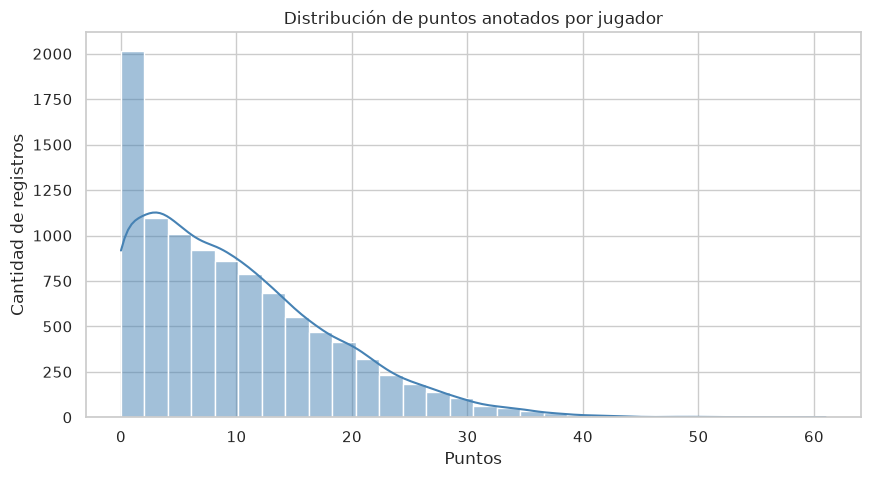

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.histplot(data=nba_sample, x="PTS", bins=30, kde=True, color="steelblue")
plt.title("Distribución de puntos anotados por jugador")
plt.xlabel("Puntos")
plt.ylabel("Cantidad de registros")
plt.show()

#### 10.2. Relación entre Minutos Jugados y Puntos
Existe una fuerte correlación positiva entre minutos y puntos, pero con alta dispersión (varianza creciente).

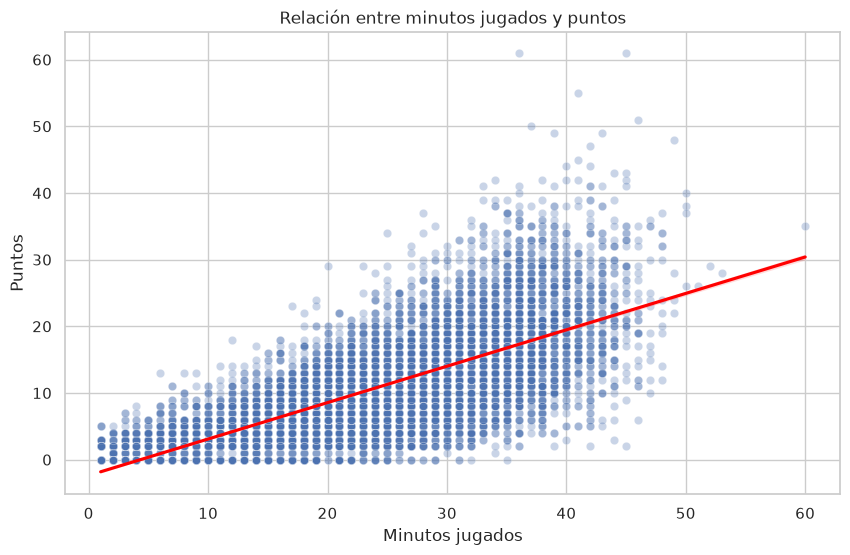

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=nba_sample, x="minutes", y="PTS", alpha=0.30)
sns.regplot(data=nba_sample, x="minutes", y="PTS", scatter=False, color="red")
plt.title("Relación entre minutos jugados y puntos")
plt.xlabel("Minutos jugados")
plt.ylabel("Puntos")
plt.show()

#### 10.3. Matriz de Correlación de Características
Observamos que `FGA` (tiros intentados) y `FTA` (tiros libres intentados) muestran la correlación lineal más alta con `PTS`.

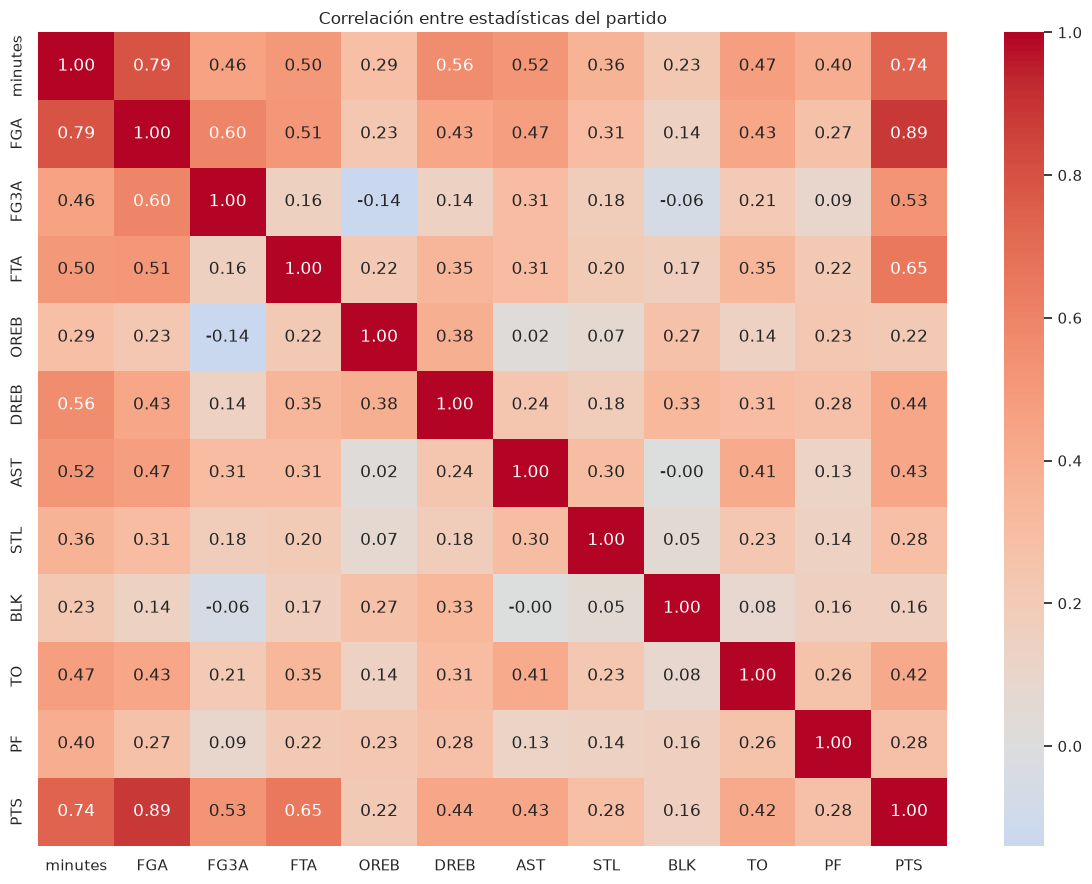

In [14]:
correlation_columns = feature_columns + [label_column]
correlation_matrix = nba_sample[correlation_columns].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación entre estadísticas del partido")
plt.tight_layout()
plt.show()

### 11. Vectorización con `VectorAssembler` (Spark ML)
A diferencia de bibliotecas locales donde se ingresan matrices NumPy, Spark ML requiere que todas las variables predictoras se empaqueten en una única columna de tipo `Vector` (ya sea `DenseVector` o `SparseVector`).
* `VectorAssembler(inputCols=..., outputCol="features")`: Transforma múltiples columnas numéricas en un vector estructurado para optimizar la serialización y el cómputo distribuido.

In [15]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

nba_vectorized = assembler.transform(nba_ml)
nba_vectorized.select("PLAYER_NAME", "features", "PTS").show(5, truncate=False)

+-----------------+-------------------------------------------------+----+
|PLAYER_NAME      |features                                         |PTS |
+-----------------+-------------------------------------------------+----+
|Bradley Beal     |[34.0,28.0,6.0,6.0,0.0,4.0,3.0,1.0,0.0,1.0,0.0]  |33.0|
|Rui Hachimura    |[25.0,6.0,1.0,3.0,2.0,5.0,1.0,0.0,0.0,3.0,4.0]   |11.0|
|Alex Len         |(11,[0,1,4,5,7,10],[12.0,5.0,3.0,2.0,1.0,2.0])   |6.0 |
|Raul Neto        |[19.0,5.0,2.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0,2.0]   |4.0 |
|Russell Westbrook|[29.0,10.0,3.0,10.0,2.0,4.0,11.0,0.0,0.0,4.0,0.0]|10.0|
+-----------------+-------------------------------------------------+----+
only showing top 5 rows



### 12. División Train/Test Distribuida (`randomSplit`)
Separamos el DataFrame distribuido en un 70% para entrenamiento y un 30% para prueba con una semilla fijada (`seed=42`) para garantizar reproducibilidad.

In [16]:
train_data, test_data = nba_vectorized.randomSplit(
    weights=[0.70, 0.30],
    seed=42
)

print("Registros de entrenamiento:", train_data.count())
print("Registros de prueba:", test_data.count())

Registros de entrenamiento: 357342


Registros de prueba: 152850


### 13. Definición y Entrenamiento de Regresión Lineal (`LinearRegression`)
Instanciamos el estimador de Regresión Lineal de Spark ML y lo ajustamos sobre el conjunto de entrenamiento mediante `.fit(train_data)`.

In [17]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(
    featuresCol="features",
    labelCol="PTS",
    predictionCol="prediction",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0
)

# Entrenamos:
lr_model = lr.fit(train_data)

Le pedimos a spark un modelo lineal sin regularización ninguna, por lo que nos advierte que si hay multicolinealidad puede sobreajustarse

### 14. Inspección de Coeficientes e Intercepto
Visualizamos el peso matemático que el modelo aprendió para cada característica en la predicción de puntos.

In [18]:
print("Intercepto:", lr_model.intercept)

for feature, coefficient in zip(feature_columns, lr_model.coefficients):
    print(f"{feature:10s}: {coefficient:.4f}")

Intercepto: -0.7406383350736909
minutes   : 0.0160
FGA       : 0.9658
FG3A      : 0.2187
FTA       : 0.8010
OREB      : -0.1095
DREB      : 0.0656
AST       : -0.0485
STL       : -0.0005
BLK       : 0.1058
TO        : 0.0072
PF        : 0.0325


### 15. Inferencia sobre el Conjunto de Prueba (`.transform()`)
Aplicamos el modelo entrenado sobre los datos no vistos (`test_data`) para generar la columna `prediction`.

In [19]:
predictions_lr = lr_model.transform(test_data)

predictions_lr.select(
    "PLAYER_NAME",
    f.col("PTS").alias("Puntos_reales"),
    f.round("prediction", 2).alias("Puntos_estimados")
).show(20, truncate=False)

+------------+-------------+----------------+
|PLAYER_NAME |Puntos_reales|Puntos_estimados|
+------------+-------------+----------------+
|Aaron Brooks|5.0          |6.58            |
|Aaron Brooks|2.0          |7.73            |
|Aaron Brooks|9.0          |5.72            |
|Aaron Brooks|5.0          |11.5            |
|Aaron Brooks|2.0          |6.82            |
|Aaron Brooks|7.0          |6.63            |
|Aaron Brooks|9.0          |10.15           |
|Aaron Brooks|13.0         |10.62           |
|Aaron Brooks|10.0         |9.64            |
|Aaron Brooks|5.0          |7.32            |
|Aaron Brooks|12.0         |10.66           |
|Aaron Brooks|18.0         |15.1            |
|Aaron Brooks|5.0          |8.15            |
|Aaron Brooks|8.0          |7.45            |
|Aaron Brooks|12.0         |9.98            |
|Aaron Brooks|14.0         |8.65            |
|Aaron Brooks|11.0         |11.27           |
|Aaron Brooks|9.0          |10.03           |
|Aaron Brooks|10.0         |10.47 

### 16. Evaluación del modelo (`RegressionEvaluator`)
Calculamos el Error Absoluto Medio (MAE), la Raíz del Error Cuadrático Medio (RMSE) y el Coeficiente de Determinación ($R^2$).

In [20]:
from pyspark.ml.evaluation import RegressionEvaluator

mae_evaluator = RegressionEvaluator(labelCol="PTS", predictionCol="prediction", metricName="mae")
mae = mae_evaluator.evaluate(predictions_lr)

rmse_evaluator = RegressionEvaluator(labelCol="PTS", predictionCol="prediction", metricName="rmse")
rmse = rmse_evaluator.evaluate(predictions_lr)

r2_evaluator = RegressionEvaluator(labelCol="PTS", predictionCol="prediction", metricName="r2")
r2 = r2_evaluator.evaluate(predictions_lr)

print("Evaluación de la regresión lineal base:")
print("----------------------------------------")
print(f"MAE : {mae:.4f} puntos")
print(f"RMSE: {rmse:.4f} puntos")
print(f"R²  : {r2:.4f}")

Evaluación de la regresión lineal base:
----------------------------------------
MAE : 2.4297 puntos
RMSE: 3.2226 puntos
R²  : 0.8373


### 17. Diagnóstico Visual: Puntos Reales vs. Predichos
Comparamos la predicción contra la línea diagonal ideal $y = x$.

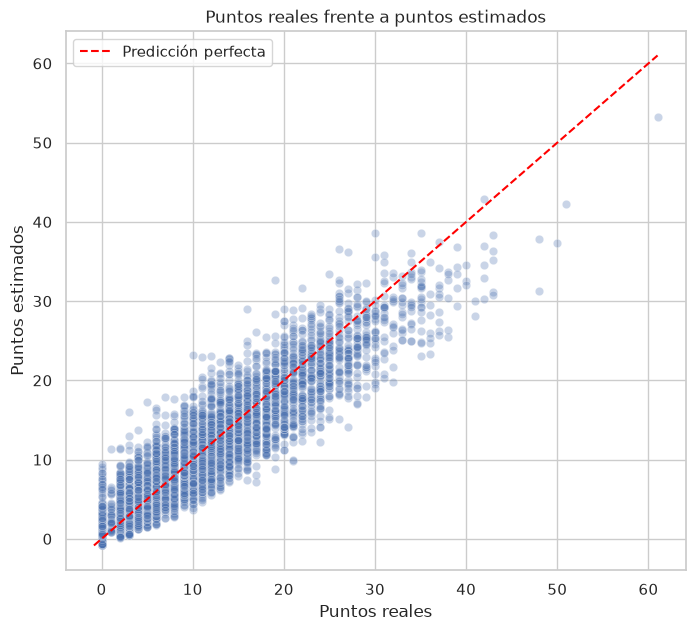

In [21]:
predictions_sample = (
    predictions_lr
    .select("PTS", "prediction")
    .limit(5000)
    .toPandas()
)

plt.figure(figsize=(8, 7))
sns.scatterplot(data=predictions_sample, x="PTS", y="prediction", alpha=0.30)
minimum = min(predictions_sample["PTS"].min(), predictions_sample["prediction"].min())
maximum = max(predictions_sample["PTS"].max(), predictions_sample["prediction"].max())
plt.plot([minimum, maximum], [minimum, maximum], color="red", linestyle="--", label="Predicción perfecta")
plt.title("Puntos reales frente a puntos estimados")
plt.xlabel("Puntos reales")
plt.ylabel("Puntos estimados")
plt.legend()
plt.show()

### 18. Análisis de Residuos ($e = y - \hat{y}$)
Calculamos los residuos para comprobar si cumplen con los supuestos de media cero y simetría, o si presentan heterocedasticidad.

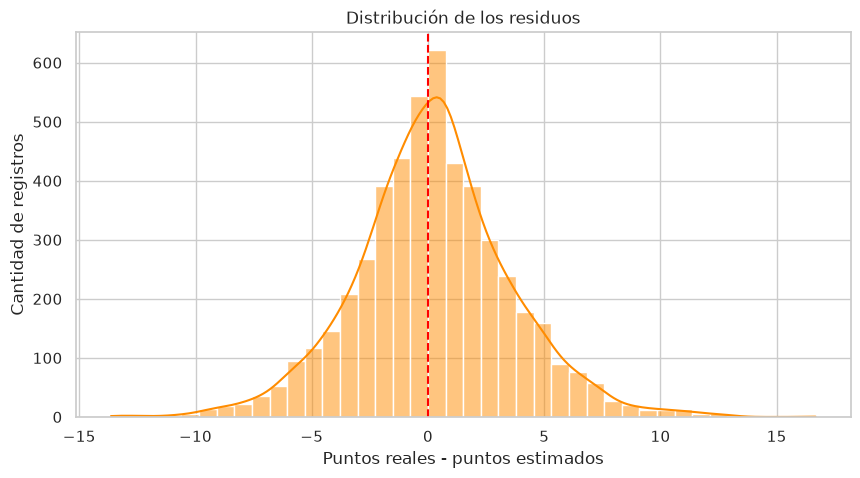

In [22]:
predictions_lr = predictions_lr.withColumn(
    "residual",
    f.col("PTS") - f.col("prediction")
)

residuals_sample = predictions_lr.select("residual").limit(5000).toPandas()

plt.figure(figsize=(10, 5))
sns.histplot(data=residuals_sample, x="residual", bins=40, kde=True, color="darkorange")
plt.axvline(x=0, color="red", linestyle="--")
plt.title("Distribución de los residuos")
plt.xlabel("Puntos reales - puntos estimados")
plt.ylabel("Cantidad de registros")
plt.show()

---
## EJERCICIO PRÁCTICO DE ASISTENCIA (Trabajo de Clase)
Instrucciones: Responde las siguientes preguntas analíticas y completa los retos propuestos a continuación. Asegúrate de ejecutar todas las celdas antes de entregar.

### Parte A: Análisis Crítico y Conceptual

#### 1. Prevención de Fuga de Información
En la celda de selección de variables se excluyeron `FGM` (tiros de campo encestados), `FG3M` (triples encestados) y `FTM` (tiros libres encestados).
- Pregunta 1: Si las hubiéramos incluido en el modelo, ¿qué habría ocurrido con el valor de $R^2$ y con la utilidad real del modelo para un equipo técnico durante un partido en vivo?

Respuesta 1:

El R² sería prácticamente 1 porque esas variables permiten calcular los puntos exactos. El modelo solo repetiría esa fórmula y no serviría para anticipar la anotación. Además, para usarlo en vivo habría que trabajar con estadísticas disponibles hasta ese momento, no con los totales finales del partido.

#### 2. Arquitectura Big Data: Driver vs. Executors
En la celda de visualización exploratoria se ejecutó:
```python
nba_sample = nba_ml.sample(withReplacement=False, fraction=0.10, seed=42).limit(10000).toPandas()
```
- Pregunta 2.1: ¿Por qué es una mala práctica en entornos de producción ejecutar `df.toPandas()` directamente sobre un DataFrame masivo de Spark?
- Pregunta 2.2: ¿Qué error de infraestructura o de memoria se previene mediante el muestreo previo?

Respuesta 2:

2.1. toPandas reúne todos los datos en la memoria del driver. Con un dataset grande se pierde la ventaja de tener los datos distribuidos y se puede saturar la memoria.

2.2. El muestreo y el límite de filas reducen ese riesgo y ayudan a evitar un OutOfMemoryError o que se cierre el proceso por falta de memoria.

#### 3. VectorAssembler en Spark ML
- Pregunta 3: A diferencia de `scikit-learn` donde se suministran matrices 2D de Pandas o NumPy, ¿por qué Spark ML comprime todas las variables independientes en una única columna de tipo `Vector` (`features`)? ¿Qué beneficios ofrece esta abstracción para la ejecución distribuida?

Respuesta 3:

VectorAssembler junta las variables de cada fila en un vector con un orden fijo. Así los algoritmos de Spark ML reciben el mismo formato y pueden procesarlo en distintas particiones. También permite usar vectores dispersos para ahorrar espacio cuando hay muchos ceros. No significa que todos los datos se junten en el driver.

#### 4. Interpretación de Coeficientes
Revisa los coeficientes calculados por el modelo (`lr_model.coefficients`).
- Pregunta 4.1: ¿Cuáles variables tienen el mayor impacto positivo en la estimación de puntos?
- Pregunta 4.2: ¿Tiene sentido deportivo la magnitud y signo de estos coeficientes? ¿Hay algún coeficiente que te llame la atención?

Respuesta 4:

4.1. Los coeficientes positivos más altos son FGA con 0.9658, FTA con 0.8010 y FG3A con 0.2187. Representan el cambio estimado en puntos por una unidad adicional, manteniendo las demás variables constantes. Las escalas son distintas, así que no son una medida directa de importancia.

4.2. Tiene sentido que intentar más tiros se relacione con más puntos. Me llama la atención que OREB tenga un coeficiente de -0.1095 y AST de -0.0485. No significa que rebotear o asistir cause menos puntos, sino que esa es su relación al controlar las otras estadísticas. FG3A ya forma parte de FGA, así que su coeficiente refleja el efecto adicional de intentar un triple.

#### 5. Diagnóstico de Residuos y Outliers
Observa la gráfica de dispersión entre puntos reales y estimados, y el histograma de residuos.
- Pregunta 5.1: Para jugadores con puntuaciones atípicas (ej. más de 45 puntos en una sola noche), ¿el modelo tiende a sobreestimar o subestimar su producción real?
- Pregunta 5.2: ¿Qué implicación tiene esto sobre los supuestos de la regresión lineal (homocedasticidad, linealidad)?

Respuesta 5:

5.1. El modelo tiende a subestimar las anotaciones altas. En prueba hay 90 registros con más de 45 puntos y subestima el 94.4 %. El residuo promedio es de 8.37 puntos, por lo que los puntos reales suelen superar la predicción.

5.2. Esto sugiere que la relación lineal no captura bien las noches de anotación extrema. La dispersión también sugiere que el error puede cambiar según el nivel de anotación, lo que pondría en duda la homocedasticidad. El histograma por sí solo no confirma ese supuesto.

---
### Parte B: Retos de Modelado

#### 🛠️ Reto 1: Feature Engineering Distribuido
Crea al menos dos nuevas variables explicativas usando `pyspark.sql.functions` sobre `nba_ml`. Ejemplos:
- `total_rebounds = OREB + DREB`
- `shots_per_minute = FGA / minutes`
- `ast_to_to_ratio = AST / (TO + 1)`

Re-entrena la regresión lineal con las nuevas variables añadidas a `feature_columns`. Compara el nuevo $R^2$ y RMSE.

In [23]:
nba_ml_reto1 = (
    nba_ml
    .withColumn("shots_per_minute", f.col("FGA") / f.col("minutes"))
    .withColumn("ast_to_to_ratio", f.col("AST") / (f.col("TO") + f.lit(1.0)))
)
feature_columns_reto1 = feature_columns + ["shots_per_minute", "ast_to_to_ratio"]

def add_features(df):
    return (
        df.drop("features")
        .withColumn("shots_per_minute", f.col("FGA") / f.col("minutes"))
        .withColumn("ast_to_to_ratio", f.col("AST") / (f.col("TO") + f.lit(1.0)))
    )

train_reto1 = add_features(train_data).cache()
test_reto1 = add_features(test_data).cache()
assembler_reto1 = VectorAssembler(inputCols=feature_columns_reto1, outputCol="features")
model_reto1 = LinearRegression(
    featuresCol="features", labelCol="PTS", maxIter=100, regParam=0.0
).fit(assembler_reto1.transform(train_reto1))
predictions_reto1 = model_reto1.transform(assembler_reto1.transform(test_reto1))

def evaluate_model(name, predictions):
    return (
        name,
        float(mae_evaluator.evaluate(predictions)),
        float(rmse_evaluator.evaluate(predictions)),
        float(r2_evaluator.evaluate(predictions))
    )

results = [("Base", float(mae), float(rmse), float(r2))]
results.append(evaluate_model("Nuevas variables", predictions_reto1))
spark.createDataFrame(results, ["Modelo", "MAE", "RMSE", "R2"]).show(truncate=False)
print(f"Cambio en R²: {results[1][3] - r2:.4f}")
print(f"Cambio en RMSE: {results[1][2] - rmse:.4f}")
nba_ml_reto1.select("shots_per_minute", "ast_to_to_ratio").show(5)

+----------------+------------------+------------------+------------------+
|Modelo          |MAE               |RMSE              |R2                |
+----------------+------------------+------------------+------------------+
|Base            |2.429740408708188 |3.2225718403289974|0.8373157130840228|
|Nuevas variables|2.4227340594555518|3.221645027039485 |0.837409275793976 |
+----------------+------------------+------------------+------------------+

Cambio en R²: 0.0001
Cambio en RMSE: -0.0009


+------------------+---------------+
|  shots_per_minute|ast_to_to_ratio|
+------------------+---------------+
|0.8235294117647058|            1.5|
|              0.24|           0.25|
|0.4166666666666667|            0.0|
|0.2631578947368421|            1.0|
|0.3448275862068966|            2.2|
+------------------+---------------+
only showing top 5 rows



Las nuevas variables mejoraron muy poco el resultado. El R² pasó de 0.837316 a 0.837409 y el RMSE de 3.222572 a 3.221645. Se usaron las mismas filas de entrenamiento y prueba del modelo base para comparar de forma consistente.

#### 🛠️ Reto 2: Pipeline Formal de Spark ML (`pyspark.ml.Pipeline`)
Construye un pipeline que encapsule:
1. `VectorAssembler`
2. `StandardScaler` (para normalizar las variables independientes)
3. `LinearRegression`

Ajusta el pipeline sobre los datos de entrenamiento y evalúa en prueba.

In [24]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StandardScaler

pipeline = Pipeline(stages=[
    VectorAssembler(inputCols=feature_columns_reto1, outputCol="features"),
    StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=False),
    LinearRegression(featuresCol="scaled_features", labelCol="PTS", maxIter=100, regParam=0.0)
])
pipeline_model = pipeline.fit(train_reto1)
predictions_pipeline = pipeline_model.transform(test_reto1)
results.append(evaluate_model("Pipeline", predictions_pipeline))
spark.createDataFrame([results[-1]], ["Modelo", "MAE", "RMSE", "R2"]).show(truncate=False)

+--------+-----------------+------------------+------------------+
|Modelo  |MAE              |RMSE              |R2                |
+--------+-----------------+------------------+------------------+
|Pipeline|2.422734059456078|3.2216450270393997|0.8374092757939845|
+--------+-----------------+------------------+------------------+



El pipeline obtuvo prácticamente las mismas métricas que el modelo con nuevas variables. El escalador se ajustó solo con entrenamiento. Escalar cambia las unidades, pero no debería cambiar las predicciones de esta regresión sin regularización.

#### 🛠️ Reto 3: Comparación con Algoritmo Alternativo / Regularización
Entrena un modelo alternativo para predecir `PTS`:
- Opción A: Regresión Lineal regularizada (Lasso/Ridge variando `regParam` y `elasticNetParam`).
- Opción B: Un ensamble no lineal como `RandomForestRegressor` (`from pyspark.ml.regression import RandomForestRegressor`).

Genera una tabla comparativa final con métricas de MAE, RMSE y $R^2$ en el conjunto de prueba.

In [25]:
regularized_predictions = {}
for name, reg_param, elastic_net in [
    ("Ridge 0.1", 0.1, 0.0),
    ("Ridge 1.0", 1.0, 0.0),
    ("Lasso 0.1", 0.1, 1.0)
]:
    regularized_pipeline = Pipeline(stages=[
        VectorAssembler(inputCols=feature_columns_reto1, outputCol="features"),
        StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=False),
        LinearRegression(
            featuresCol="scaled_features", labelCol="PTS", maxIter=100,
            regParam=reg_param, elasticNetParam=elastic_net
        )
    ])
    model = regularized_pipeline.fit(train_reto1)
    predicted = model.transform(test_reto1)
    regularized_predictions[name] = predicted
    results.append(evaluate_model(name, predicted))

comparison = spark.createDataFrame(results, ["Modelo", "MAE", "RMSE", "R2"])
comparison.orderBy("RMSE").show(truncate=False)

+----------------+------------------+------------------+------------------+
|Modelo          |MAE               |RMSE              |R2                |
+----------------+------------------+------------------+------------------+
|Pipeline        |2.422734059456078 |3.2216450270393997|0.8374092757939845|
|Nuevas variables|2.4227340594555518|3.221645027039485 |0.837409275793976 |
|Base            |2.429740408708188 |3.2225718403289974|0.8373157130840228|
|Ridge 0.1       |2.4312638167879355|3.2241579579506183|0.8371555305164976|
|Lasso 0.1       |2.432004993306214 |3.229422228115435 |0.8366233251219098|
|Ridge 1.0       |2.523825072269287 |3.3222269113023986|0.8270984143372102|
+----------------+------------------+------------------+------------------+



Ridge y Lasso no mejoraron los resultados con estos valores. Ridge con 1.0 tuvo el mayor RMSE, de 3.3222. Esta es una comparación en prueba; para elegir parámetros haría falta validación dentro del entrenamiento.

#### 🛠️ Reto 4: Evaluación por Segmento de Jugador
Filtra el conjunto de prueba en dos segmentos:
- Titulares / alto volumen: `minutes > 25`
- Suplentes / rol secundario: `minutes <= 25`

Calcula el MAE y RMSE para cada grupo. Concluye para qué tipo de jugador el modelo es más confiable.

In [26]:
segment_results = []
for name, condition in [
    ("Más de 25 minutos", f.col("minutes") > 25),
    ("Hasta 25 minutos", f.col("minutes") <= 25)
]:
    segment = predictions_lr.filter(condition)
    segment_results.append((
        name, segment.count(),
        float(mae_evaluator.evaluate(segment)),
        float(rmse_evaluator.evaluate(segment))
    ))

spark.createDataFrame(segment_results, ["Segmento", "Registros", "MAE", "RMSE"]).show(truncate=False)
print("Evaluación por segmento del modelo base.")
print("Menor MAE:", min(segment_results, key=lambda row: row[2])[0])
print("Menor RMSE:", min(segment_results, key=lambda row: row[3])[0])

predictions_lr.filter(f.col("PTS") > 45).agg(
    f.count("*").alias("Partidos_mas_de_45"),
    f.avg("residual").alias("Residuo_promedio"),
    f.avg((f.col("residual") > 0).cast("double")).alias("Proporcion_subestimada")
).show()

+-----------------+---------+------------------+------------------+
|Segmento         |Registros|MAE               |RMSE              |
+-----------------+---------+------------------+------------------+
|Más de 25 minutos|65017    |3.1354138569588046|3.9758704068071604|
|Hasta 25 minutos |87833    |1.9073767118640745|2.524082467857305 |
+-----------------+---------+------------------+------------------+

Evaluación por segmento del modelo base.
Menor MAE: Hasta 25 minutos
Menor RMSE: Hasta 25 minutos


+------------------+-----------------+----------------------+
|Partidos_mas_de_45| Residuo_promedio|Proporcion_subestimada|
+------------------+-----------------+----------------------+
|                90|8.371927524950044|    0.9444444444444444|
+------------------+-----------------+----------------------+



El modelo base es más confiable en error absoluto para jugadores con hasta 25 minutos. Su MAE fue de 1.91 puntos y su RMSE de 2.52, frente a 3.14 y 3.98 para quienes jugaron más de 25 minutos. Esto no demuestra un menor error relativo, porque los jugadores con menos minutos también suelen anotar menos.